# Predictive Modeling and Optimization for Logistics Operations

## Project Overview

This project applies predictive modeling and optimization techniques to a logistics problem.

The objective is to predict delivery time for shipments using operational factors such as distance, traffic, weather, package weight, vehicle type, driver experience, number of stops, and delivery hour.

The project covers:

- Data simulation
- Data cleaning
- Exploratory Data Analysis
- Feature engineering
- Predictive modeling
- Model evaluation
- Cross-validation
- Hyperparameter tuning
- Feature importance analysis
- Logistics optimization
- Business recommendations

### Target Variable

Delivery_Time_Minutes

### Business Objective

To predict delivery times accurately and use these predictions to improve driver allocation, route planning, scheduling, and overall logistics efficiency.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
np.random.seed(42)

n = 1500

distance = np.random.uniform(2, 50, n)
traffic = np.random.choice(
    ["Low", "Medium", "High"],
    n,
    p=[0.35, 0.40, 0.25]
)

weather = np.random.choice(
    ["Clear", "Rain", "Storm"],
    n,
    p=[0.65, 0.25, 0.10]
)

package_weight = np.random.uniform(0.5, 25, n)

vehicle = np.random.choice(
    ["Bike", "Van", "Truck"],
    n,
    p=[0.35, 0.45, 0.20]
)

driver_experience = np.random.uniform(0, 15, n)

stop_count = np.random.randint(1, 16, n)

hour = np.random.randint(6, 23, n)

# Convert categorical effects into delivery-time impact
traffic_effect = np.select(
    [
        traffic == "Low",
        traffic == "Medium",
        traffic == "High"
    ],
    [0, 12, 28]
)

weather_effect = np.select(
    [
        weather == "Clear",
        weather == "Rain",
        weather == "Storm"
    ],
    [0, 10, 25]
)

vehicle_effect = np.select(
    [
        vehicle == "Bike",
        vehicle == "Van",
        vehicle == "Truck"
    ],
    [0, 5, 10]
)

peak_effect = np.where(
    ((hour >= 8) & (hour <= 10)) |
    ((hour >= 17) & (hour <= 20)),
    15,
    0
)

# Simulate delivery time
delivery_time = (
    12
    + distance * 2.2
    + package_weight * 0.35
    + stop_count * 3
    - driver_experience * 0.8
    + traffic_effect
    + weather_effect
    + vehicle_effect
    + peak_effect
    + np.random.normal(0, 8, n)
)

df = pd.DataFrame({
    "Distance_KM": distance,
    "Traffic_Level": traffic,
    "Weather": weather,
    "Package_Weight_KG": package_weight,
    "Vehicle_Type": vehicle,
    "Driver_Experience_Years": driver_experience,
    "Stop_Count": stop_count,
    "Hour_of_Day": hour,
    "Delivery_Time_Minutes": delivery_time
})

df.head()

,Distance_KM,Traffic_Level,Weather,Package_Weight_KG,Vehicle_Type,Driver_Experience_Years,Stop_Count,Hour_of_Day,Delivery_Time_Minutes
0,19.977926,Medium,Rain,15.182833,Van,8.143172,5,15,112.567903
1,47.634287,Medium,Rain,13.085842,Bike,12.493404,2,8,158.432962
2,37.135709,Low,Clear,7.560521,Truck,1.876334,15,12,149.856972
3,30.735607,Low,Clear,0.658377,Van,1.946744,12,15,116.115723
4,9.488895,Medium,Clear,12.657861,Bike,8.352275,13,18,82.529328


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (1500, 9)

Column Names:
['Distance_KM', 'Traffic_Level', 'Weather', 'Package_Weight_KG', 'Vehicle_Type', 'Driver_Experience_Years', 'Stop_Count', 'Hour_of_Day', 'Delivery_Time_Minutes']

Data Types:
Distance_KM                float64
Traffic_Level               object
Weather                     object
Package_Weight_KG          float64
Vehicle_Type                object
Driver_Experience_Years    float64
Stop_Count                   int64
Hour_of_Day                  int64
Delivery_Time_Minutes      float64
dtype: object

Missing Values:
Distance_KM                0
Traffic_Level              0
Weather                    0
Package_Weight_KG          0
Vehicle_Type               0
Driver_Experience_Years    0
Stop_Count                 0
Hour_of_Day                0
Delivery_Time_Minutes      0
dtype: int64

Duplicate Rows:
0


In [ ]:
df.describe()

,Distance_KM,Package_Weight_KG,Driver_Experience_Years,Stop_Count,Hour_of_Day,Delivery_Time_Minutes
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,25.969140,12.731958,7.265522,7.912000,14.260000,118.541502
std,14.112723,7.096699,4.266513,4.301386,4.899837,37.825858
min,2.222337,0.505562,0.003644,1.000000,6.000000,16.019957
25%,13.402109,6.587680,3.608249,4.000000,10.000000,88.853732
50%,26.314964,12.490720,7.210756,8.000000,14.000000,117.858946
75%,38.176129,18.912167,10.786982,12.000000,19.000000,146.547044
max,49.986448,24.984082,14.961344,15.000000,22.000000,235.485318


In [ ]:
df.describe(include="object")

,Traffic_Level,Weather,Vehicle_Type
count,1500,1500,1500
unique,3,3,3
top,Medium,Clear,Van
freq,600,999,669


In [ ]:
print("Minimum delivery time:", df["Delivery_Time_Minutes"].min())
print("Maximum delivery time:", df["Delivery_Time_Minutes"].max())

print("\nUnique traffic levels:")
print(df["Traffic_Level"].unique())

print("\nUnique weather conditions:")
print(df["Weather"].unique())

print("\nUnique vehicle types:")
print(df["Vehicle_Type"].unique())

Minimum delivery time: 16.01995741376679
Maximum delivery time: 235.48531797537692

Unique traffic levels:
['Medium' 'Low' 'High']

Unique weather conditions:
['Rain' 'Clear' 'Storm']

Unique vehicle types:
['Van' 'Bike' 'Truck']


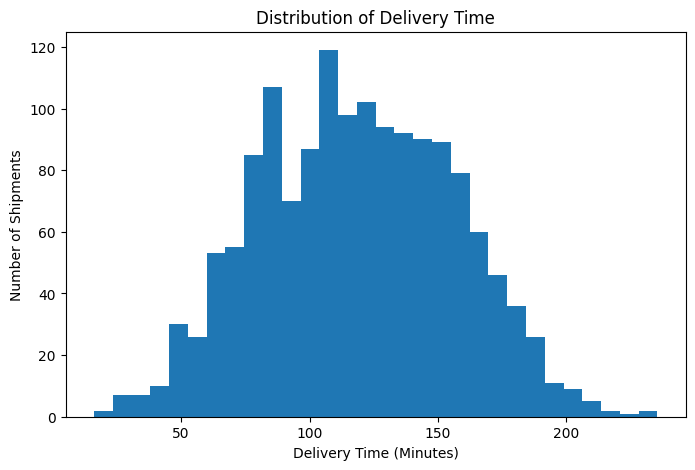

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Delivery_Time_Minutes"], bins=30)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Shipments")

plt.show()

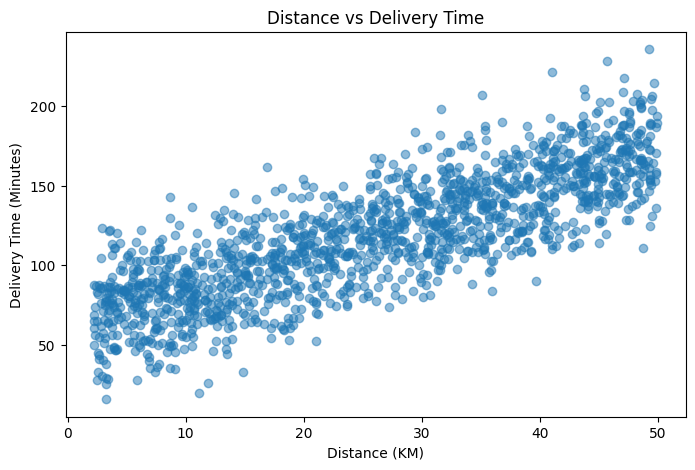

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Distance_KM"],
    df["Delivery_Time_Minutes"],
    alpha=0.5
)

plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (KM)")
plt.ylabel("Delivery Time (Minutes)")

plt.show()

In [ ]:
traffic_avg = df.groupby(
    "Traffic_Level"
)["Delivery_Time_Minutes"].mean()

print(traffic_avg)

Traffic_Level
High      135.371695
Low       106.741125
Medium    118.061656
Name: Delivery_Time_Minutes, dtype: float64


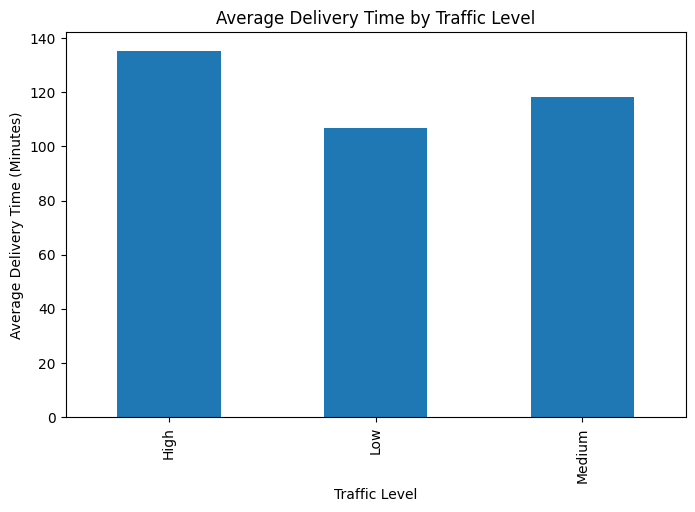

In [ ]:
traffic_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

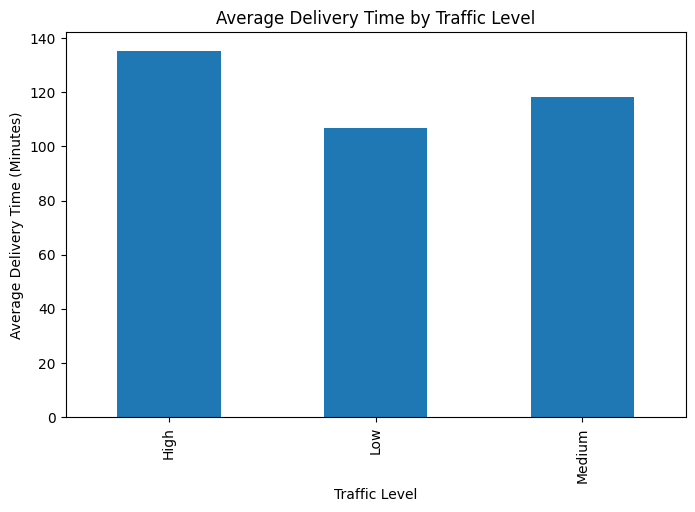

In [ ]:
traffic_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

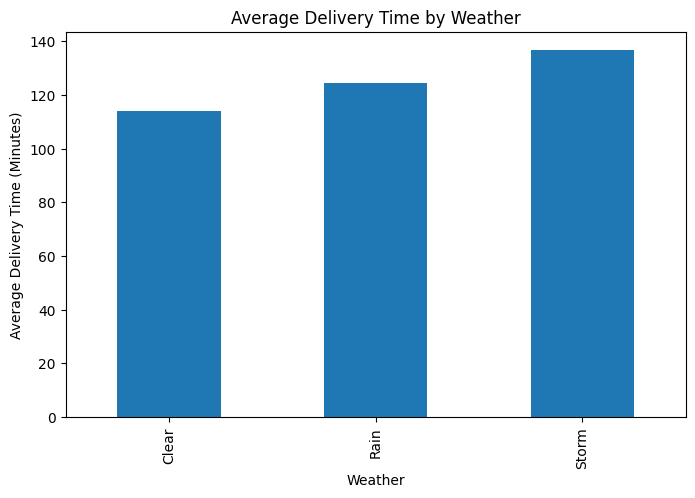

In [ ]:
weather_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Delivery Time by Weather")
plt.xlabel("Weather")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

In [ ]:
vehicle_avg = df.groupby(
    "Vehicle_Type"
)["Delivery_Time_Minutes"].mean()

print(vehicle_avg)

Vehicle_Type
Bike     112.856920
Truck    126.099346
Van      119.664313
Name: Delivery_Time_Minutes, dtype: float64


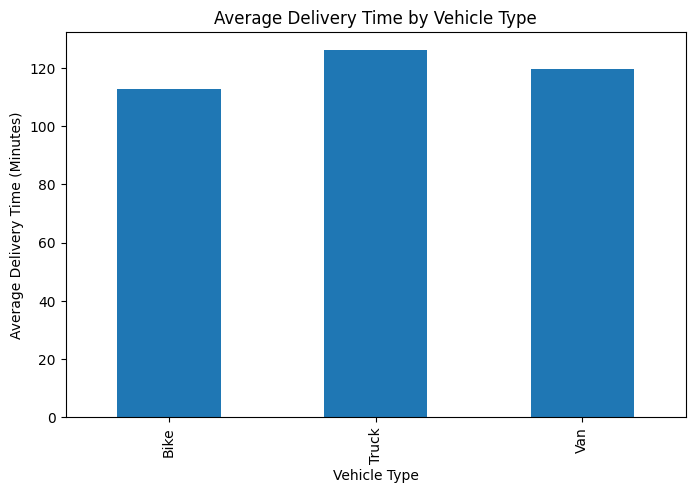

In [ ]:
vehicle_avg.plot(kind="bar", figsize=(8,5))

plt.title("Average Delivery Time by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Delivery Time (Minutes)")

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

print(correlation["Delivery_Time_Minutes"].sort_values(ascending=False))

Delivery_Time_Minutes      1.000000
Distance_KM                0.817638
Stop_Count                 0.304316
Package_Weight_KG          0.084516
Hour_of_Day                0.038784
Driver_Experience_Years   -0.108161
Name: Delivery_Time_Minutes, dtype: float64


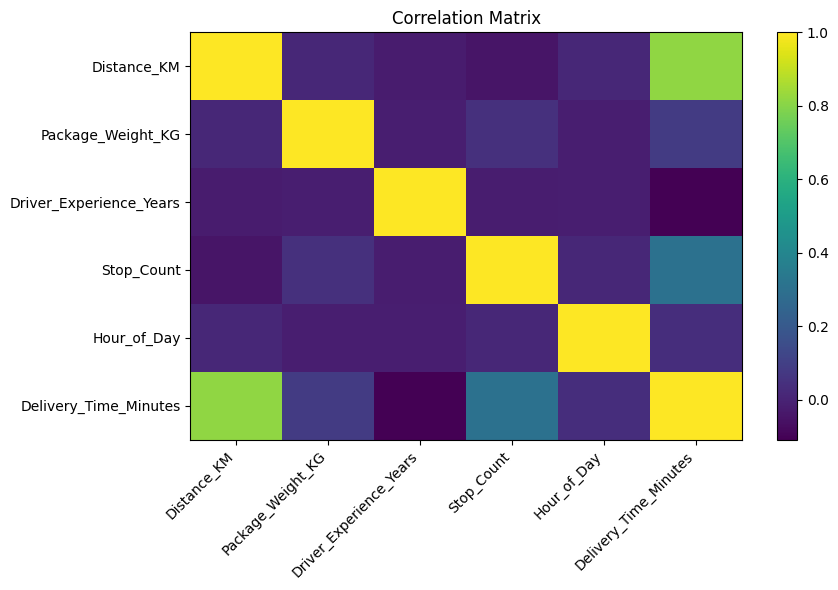

In [ ]:
plt.figure(figsize=(9,6))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [ ]:
df["Peak_Hour"] = np.where(
    ((df["Hour_of_Day"] >= 8) & (df["Hour_of_Day"] <= 10)) |
    ((df["Hour_of_Day"] >= 17) & (df["Hour_of_Day"] <= 20)),
    1,
    0
)

df.head()

,Distance_KM,Traffic_Level,Weather,Package_Weight_KG,Vehicle_Type,Driver_Experience_Years,Stop_Count,Hour_of_Day,Delivery_Time_Minutes,Peak_Hour
0,19.977926,Medium,Rain,15.182833,Van,8.143172,5,15,112.567903,0
1,47.634287,Medium,Rain,13.085842,Bike,12.493404,2,8,158.432962,1
2,37.135709,Low,Clear,7.560521,Truck,1.876334,15,12,149.856972,0
3,30.735607,Low,Clear,0.658377,Van,1.946744,12,15,116.115723,0
4,9.488895,Medium,Clear,12.657861,Bike,8.352275,13,18,82.529328,1


In [ ]:
X = df.drop(columns=["Delivery_Time_Minutes"])

y = df["Delivery_Time_Minutes"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Delivery_Time_Minutes")

Features:
['Distance_KM', 'Traffic_Level', 'Weather', 'Package_Weight_KG', 'Vehicle_Type', 'Driver_Experience_Years', 'Stop_Count', 'Hour_of_Day', 'Peak_Hour']

Target:
Delivery_Time_Minutes


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1200
Testing samples: 300


In [ ]:
categorical_features = [
    "Traffic_Level",
    "Weather",
    "Vehicle_Type"
]

numerical_features = [
    "Distance_KM",
    "Package_Weight_KG",
    "Driver_Experience_Years",
    "Stop_Count",
    "Hour_of_Day",
    "Peak_Hour"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

In [ ]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("--------------------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression Results
--------------------------
MAE : 6.22
RMSE: 7.6
R²  : 0.9579


In [ ]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
---------------------
MAE : 9.45
RMSE: 11.87
R²  : 0.8972


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,6.219306,7.600453,0.957850
1,Random Forest,9.445820,11.867519,0.897238


In [ ]:
results.sort_values(
    by="MAE"
)

,Model,MAE,RMSE,R2
0,Linear Regression,6.219306,7.600453,0.957850
1,Random Forest,9.445820,11.867519,0.897238


In [ ]:
cv_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

cv_mae = -cv_scores

print("Cross-validation MAE scores:")
print(cv_mae)

print("\nAverage CV MAE:",
      round(cv_mae.mean(), 2))

print("Standard deviation:",
      round(cv_mae.std(), 2))

Cross-validation MAE scores:
[9.47698604 9.52461784 9.79761591 9.92982656 9.83896005]

Average CV MAE: 9.71
Standard deviation: 0.18


In [ ]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 20, None],
    "model__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(-grid_search.best_score_)

Best Parameters:
{'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best CV MAE:
9.712926833974098


In [ ]:
best_model = grid_search.best_estimator_

tuned_predictions = best_model.predict(X_test)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

print("Tuned Random Forest Results")
print("---------------------------")
print("MAE :", round(tuned_mae, 2))
print("RMSE:", round(tuned_rmse, 2))
print("R²  :", round(tuned_r2, 4))

Tuned Random Forest Results
---------------------------
MAE : 9.45
RMSE: 11.87
R²  : 0.8972


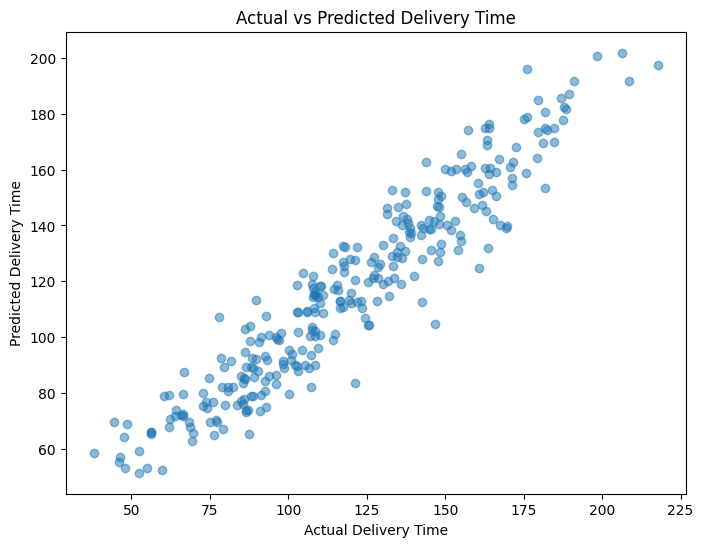

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    tuned_predictions,
    alpha=0.5
)

plt.xlabel("Actual Delivery Time")
plt.ylabel("Predicted Delivery Time")
plt.title("Actual vs Predicted Delivery Time")

plt.show()

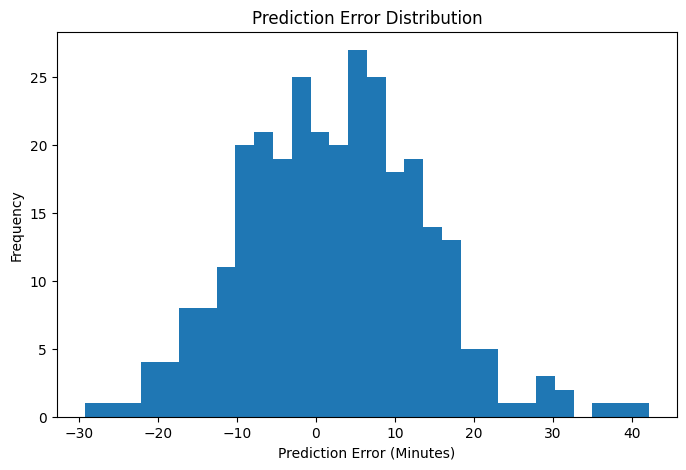

In [ ]:
errors = y_test - tuned_predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error (Minutes)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
rf_estimator = best_model.named_steps["model"]

encoded_features = (
    best_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "Feature": encoded_features,
    "Importance": rf_estimator.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
9,numerical__Distance_KM,0.699908
12,numerical__Stop_Count,0.120892
0,categorical__Traffic_Level_High,0.032250
1,categorical__Traffic_Level_Low,0.030835
11,numerical__Driver_Experience_Years,0.021620
10,numerical__Package_Weight_KG,0.021603
14,numerical__Peak_Hour,0.020595
13,numerical__Hour_of_Day,0.013277
3,categorical__Weather_Clear,0.013011
5,categorical__Weather_Storm,0.010259


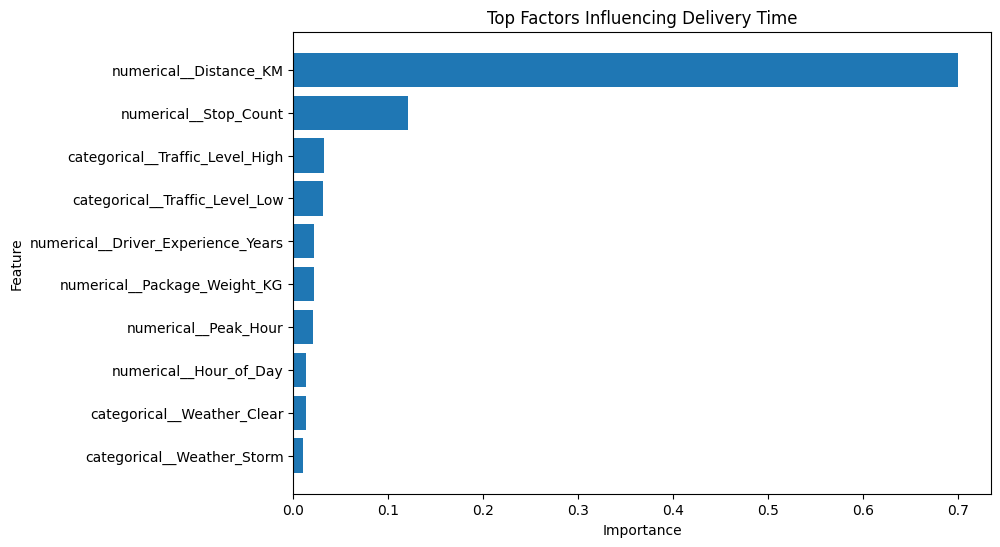

In [ ]:
top_features = importance.head(10)

plt.figure(figsize=(9,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Factors Influencing Delivery Time")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
analysis_df = X_test.copy()

analysis_df["Actual_Delivery_Time"] = y_test.values
analysis_df["Predicted_Delivery_Time"] = tuned_predictions

analysis_df["Delay_Risk"] = np.where(
    analysis_df["Predicted_Delivery_Time"] > 100,
    "High Risk",
    "Normal"
)

analysis_df.head()

,Distance_KM,Traffic_Level,Weather,Package_Weight_KG,Vehicle_Type,Driver_Experience_Years,Stop_Count,Hour_of_Day,Peak_Hour,Actual_Delivery_Time,Predicted_Delivery_Time,Delay_Risk
1116,6.391368,Medium,Storm,21.989451,Truck,14.374915,2,15,0,79.186608,67.178586,Normal
1368,10.624789,Low,Clear,20.421979,Bike,9.736209,3,6,0,54.902508,53.225419,Normal
422,6.377893,Medium,Rain,15.137016,Bike,2.676760,12,20,1,109.500111,96.244536,Normal
413,29.525019,Medium,Clear,5.288721,Van,0.739495,4,10,1,130.137798,118.861867,High Risk
451,28.803404,Low,Rain,1.755955,Truck,0.948940,15,17,1,148.350266,143.237278,High Risk


In [ ]:
risk_summary = (
    analysis_df["Delay_Risk"]
    .value_counts()
)

print(risk_summary)

Delay_Risk
High Risk    196
Normal       104
Name: count, dtype: int64


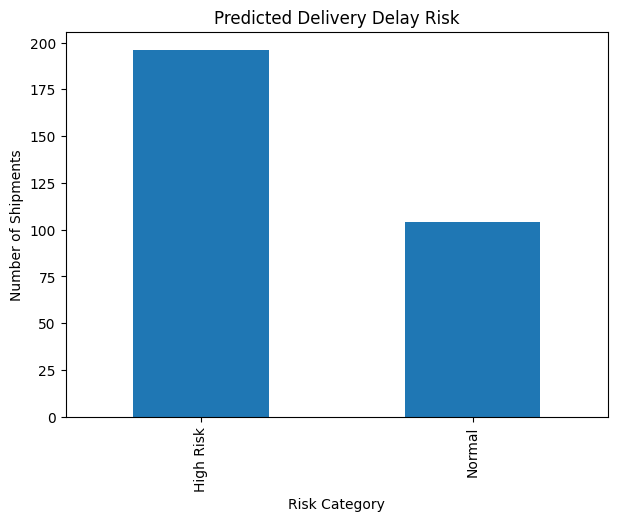

In [ ]:
risk_summary.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Predicted Delivery Delay Risk")
plt.xlabel("Risk Category")
plt.ylabel("Number of Shipments")

plt.show()

## Logistics Optimization Strategy

The predictive model can be converted into operational decisions.

### 1. Dynamic Driver Allocation
Shipments with high predicted delivery times should receive priority when allocating available drivers.

### 2. Traffic-Aware Scheduling
High-risk shipments predicted during peak traffic periods should be dispatched earlier whenever possible.

### 3. Route Prioritization
Routes with high predicted delivery times should be reviewed for alternative routing or delivery sequencing.

### 4. Vehicle Matching
Vehicle allocation should consider package weight, distance, and expected delivery duration.

### 5. Stop Consolidation
Nearby deliveries should be grouped where possible to reduce unnecessary travel and total route time.

### 6. Proactive Customer Communication
Customers associated with high predicted delivery times can be notified before a delay occurs.

### 7. Resource Planning
Predictions can be aggregated by hour and route to estimate future driver and vehicle requirements.

In [ ]:
optimization_summary = pd.DataFrame({
    "Strategy": [
        "Dynamic Driver Allocation",
        "Traffic-Aware Scheduling",
        "Route Prioritization",
        "Vehicle Matching",
        "Stop Consolidation",
        "Proactive Customer Communication",
        "Resource Planning"
    ],
    "Expected Benefit": [
        "Reduce overloaded routes",
        "Reduce peak-hour delays",
        "Focus resources on high-risk routes",
        "Improve vehicle utilization",
        "Reduce unnecessary travel",
        "Improve customer satisfaction",
        "Improve staffing and fleet planning"
    ]
})

optimization_summary

,Strategy,Expected Benefit
0,Dynamic Driver Allocation,Reduce overloaded routes
1,Traffic-Aware Scheduling,Reduce peak-hour delays
2,Route Prioritization,Focus resources on high-risk routes
3,Vehicle Matching,Improve vehicle utilization
4,Stop Consolidation,Reduce unnecessary travel
5,Proactive Customer Communication,Improve customer satisfaction
6,Resource Planning,Improve staffing and fleet planning


In [ ]:
final_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],
    "Linear Regression": [
        linear_mae,
        linear_rmse,
        linear_r2
    ],
    "Tuned Random Forest": [
        tuned_mae,
        tuned_rmse,
        tuned_r2
    ]
})

final_results

,Metric,Linear Regression,Tuned Random Forest
0,MAE,6.219306,9.447053
1,RMSE,7.600453,11.869794
2,R2,0.957850,0.897198


# Final Conclusion

The project successfully developed a predictive logistics model for estimating delivery time.

Linear Regression was initially implemented as a baseline model because it is simple and interpretable. Random Forest Regression was then selected to capture nonlinear relationships between logistics variables.

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R². Five-fold cross-validation and GridSearchCV were used to validate and tune the Random Forest model.

The final model can support logistics operations by identifying shipments with high predicted delivery times. These predictions can be used for dynamic driver allocation, traffic-aware scheduling, route prioritization, vehicle matching, stop consolidation, and proactive customer communication.

Although the dataset is simulated, the workflow demonstrates how predictive analytics can be integrated into a real logistics decision-making system. Future work could use real GPS, traffic, weather, warehouse, and historical delivery data and incorporate vehicle-routing optimization algorithms.

In [58]:
df.to_csv(
    "logistics_delivery_dataset.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
